# Kode Full

In [ ]:
# # 1. Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# # 2. Install dan import library
# !pip install emoji

# import pandas as pd
# import re
# import string
# import emoji
# import nltk
# # nltk.download('stopwords')
# # from nltk.corpus import stopwords
# def preprocessing(text):
#     """Membersihkan teks untuk keperluan LSTM (sentence & aspect)."""
#     if pd.isna(text):
#         return ''

#     text = text.lower()                                    # 1. Lowercasing
#     text = emoji.replace_emoji(text, replace='')           # 2. Hapus emoji
#     text = re.sub(f"[{string.punctuation}]", '', text)     # 3. Hapus tanda baca
#     text = re.sub(r'(.)\1{2,}', r'\1', text)               # 4. Hapus huruf ganda (lebih dari 2) -> 'soooo' jadi 'so'
#     # words = text.split()                                   # 5. Hapus stopwords
#     # words = [w for w in words if w not in stop_words]
#     # text = ' '.join(words)
#     text = re.sub(r'\s+', ' ', text).strip()               # 6. Rapikan spasi

#     return text
# # Path file di Google Drive
# input_path = '/content/drive/MyDrive/Tugas Akhir/Dataset/(3.1-LSTM) Preprocessing/Movie_review_v4.csv'
# output_full_path = '/content/drive/MyDrive/Tugas Akhir/Dataset/(3.1-LSTM) Preprocessing/Movie_Review_Processed_v3.csv'
# # Load dataset
# df = pd.read_csv(input_path)
# print(f"📥 File berhasil dimuat: {input_path}")
# print(df.head())
# # ✅ Preprocessing untuk kolom Sentence dan Aspect
# df['sentence'] = df['sentence'].apply(preprocessing)
# df['aspect'] = df['aspect'].apply(preprocessing)
# # Simpan versi lengkap (semua kolom tetap ada)
# df.to_csv(output_full_path, index=False)
# print(f"✅ Dataset lengkap disimpan di: {output_full_path}")

# Setting awal

In [ ]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2. Install dan import library
!pip install emoji

import pandas as pd
import re
import string
import emoji
import nltk
from nltk.stem import WordNetLemmatizer
# nltk.download('stopwords')
# from nltk.corpus import stopwords

# Preprocessing

In [ ]:
# # 3. Stopword bahasa Inggris
# stop_words = set(stopwords.words('english'))

In [ ]:
# 🔽 Download resource NLTK
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
# ✅ Inisialisasi Lemmatizer
lemmatizer = WordNetLemmatizer()

In [ ]:
def preprocessing(text):
    """Membersihkan teks untuk keperluan LSTM (sentence & aspect) dengan lemmatization."""
    if pd.isna(text):
        return ''

    # 1. Lowercasing
    text = text.lower()

    # 2. Hapus emoji
    text = emoji.replace_emoji(text, replace='')

    # 3. Hapus tanda baca
    text = re.sub(f"[{string.punctuation}]", '', text)

    # 4. Hapus huruf ganda (lebih dari 2) -> 'soooo' jadi 'so'
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # 5. Tokenisasi manual (split kata)
    words = text.split()

    # ✅ 6. Lemmatization untuk setiap kata
    words = [lemmatizer.lemmatize(w) for w in words]

    # 7. Gabungkan kembali jadi string
    text = ' '.join(words)

    # 8. Rapikan spasi
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
# Path file di Google Drive
input_path = '/content/drive/MyDrive/Tugas Akhir/Dataset/(3.1-LSTM) Preprocessing/Movie_review_v4.csv'
output_full_path = '/content/drive/MyDrive/Tugas Akhir/Dataset/(3.1-LSTM) Preprocessing/Movie_Review_Processed_v4.csv'

In [ ]:
# Load dataset
df = pd.read_csv(input_path)
print(f"📥 File berhasil dimuat: {input_path}")
print(df.head())

📥 File berhasil dimuat: /content/drive/MyDrive/Tugas Akhir/Dataset/(3.1-LSTM) Preprocessing/Movie_review_v4.csv
                                            sentence         aspect  sentiment
0  Also, I was amazed by the great moral message ...  moral message          1
1  Sometimes a sequel exceeds expectations and se...         sequel          1
2                        The story overall is great.          story          1
3  And because of that, we get a hero who feels g...           hero          0
4  There are a lot of cameos from other character...      character          1


In [ ]:
# ✅ Preprocessing untuk kolom Sentence dan Aspect
df['sentence'] = df['sentence'].apply(preprocessing)
df['aspect'] = df['aspect'].apply(preprocessing)

In [ ]:
# Simpan versi lengkap (semua kolom tetap ada)
df.to_csv(output_full_path, index=False)
print(f"✅ Dataset lengkap disimpan di: {output_full_path}")

✅ Dataset lengkap disimpan di: /content/drive/MyDrive/Tugas Akhir/Dataset/(3.1-LSTM) Preprocessing/Movie_Review_Processed_v4.csv


In [ ]:
df.head()

,sentence,aspect,sentiment
0,also i wa amazed by the great moral message th...,moral message,1
1,sometimes a sequel exceeds expectation and set...,sequel,1
2,the story overall is great,story,1
3,and because of that we get a hero who feel gen...,hero,0
4,there are a lot of cameo from other character ...,character,1


In [ ]:
df.tail()

,sentence,aspect,sentiment
4567,the animation and visuals in this film are lik...,animation,0
4568,the animation and visuals in this film are lik...,visuals,0
4569,even the visuals which can sometimes salvage a...,visuals,0
4570,the soundtrack wa equally uninspired with a fo...,soundtrack,0
4571,the soundtrack wa equally uninspired with a fo...,score,0


# Eksplorasi Dataset 1 - Jumlah sentimen

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# --- 1. Load dataset ---
df = pd.read_csv(output_full_path)  # atau file lain yang sudah ada kolom Sentiment
print(df['sentiment'].value_counts())

sentiment
1    2386
0    2186
Name: count, dtype: int64


In [ ]:
# --- 2. Mapping angka ke label sentimen ---
sentiment_map = {1: 'Positive', 0: 'Negative'}
df['Sentiment_Label'] = df['sentiment'].map(sentiment_map)

In [ ]:
# --- 3. Hitung jumlah tiap sentimen ---
sentiment_counts = df['Sentiment_Label'].value_counts()

print(sentiment_counts)

Sentiment_Label
Positive    2386
Negative    2186
Name: count, dtype: int64


/tmp/ipython-input-3236128578.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis', ax=axes[0])


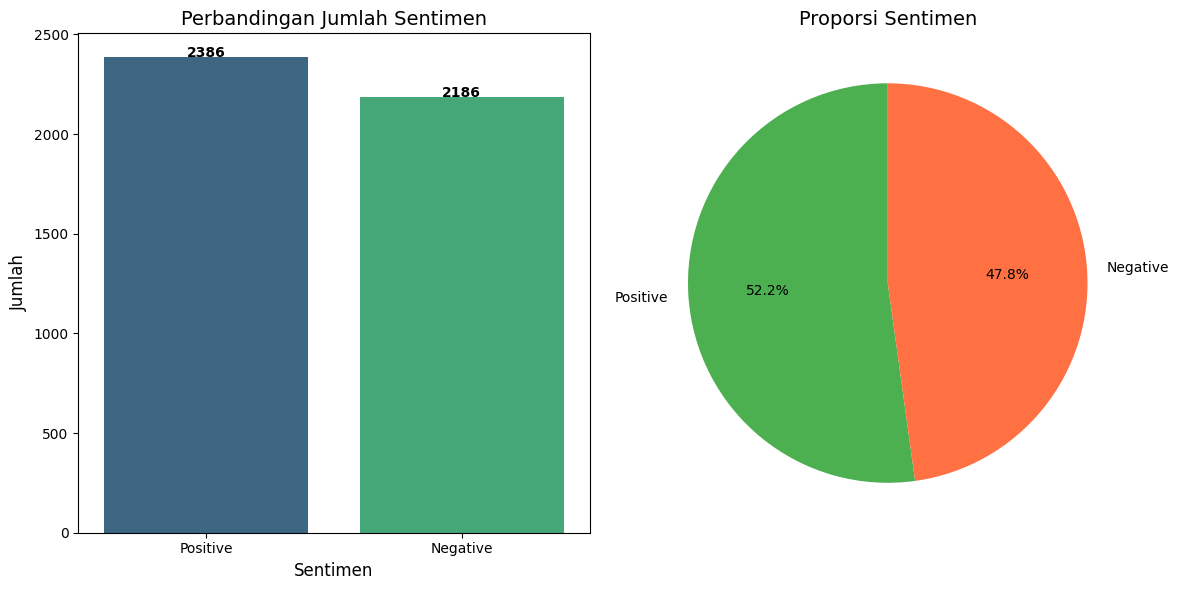

In [ ]:
# --- 4. Buat figure untuk 2 grafik berdampingan ---
fig, axes = plt.subplots(1, 2, figsize=(12,6))

## --- Grafik 1: Bar Chart ---
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis', ax=axes[0])
axes[0].set_title('Perbandingan Jumlah Sentimen', fontsize=14)
axes[0].set_xlabel('Sentimen', fontsize=12)
axes[0].set_ylabel('Jumlah', fontsize=12)

# Tambahkan label di atas bar
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

## --- Grafik 2: Pie Chart ---
colors = ['#4CAF50', '#FF7043', '#9E9E9E']  # Positive, Negative, Neutral
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proporsi Sentimen', fontsize=14)

plt.tight_layout()
plt.show()

# Eksplorasi Dataset 2 - Per Sentimen Per Aspek

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import math

In [ ]:
# --- 1. Baca dataset ---
df = pd.read_csv('/content/drive/MyDrive/Tugas Akhir/Dataset/(3.1-LSTM) Preprocessing/Movie_Review_Processed_v4.csv')

In [ ]:
# --- 2. Hitung aspek terbanyak ---
aspect_counts = df['aspect'].value_counts()

In [ ]:
# --- 3. Ambil semua aspek (atau batasi sampai tertentu) ---
all_aspects = aspect_counts.index.tolist()

In [ ]:
# --- 4. Tentukan jumlah grafik (20 aspek per grafik) ---
batch_size = 20
num_batches = math.ceil(len(all_aspects) / batch_size)

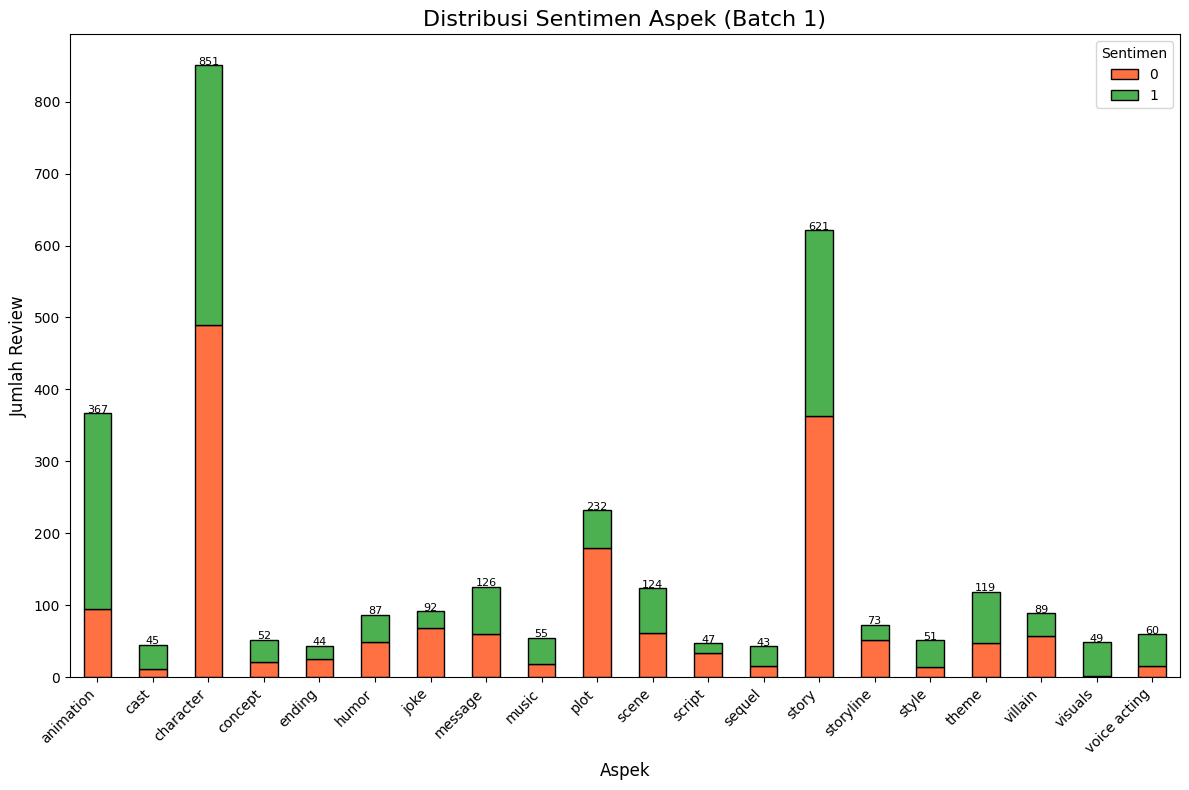

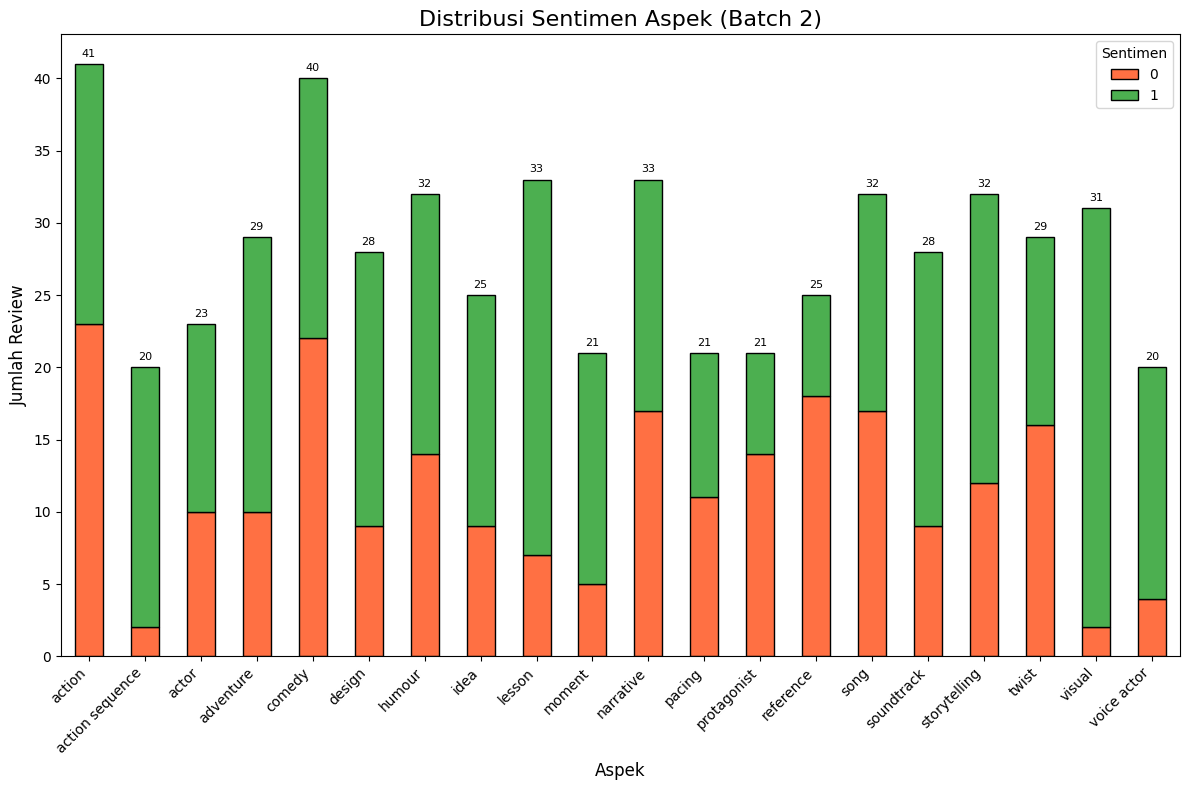

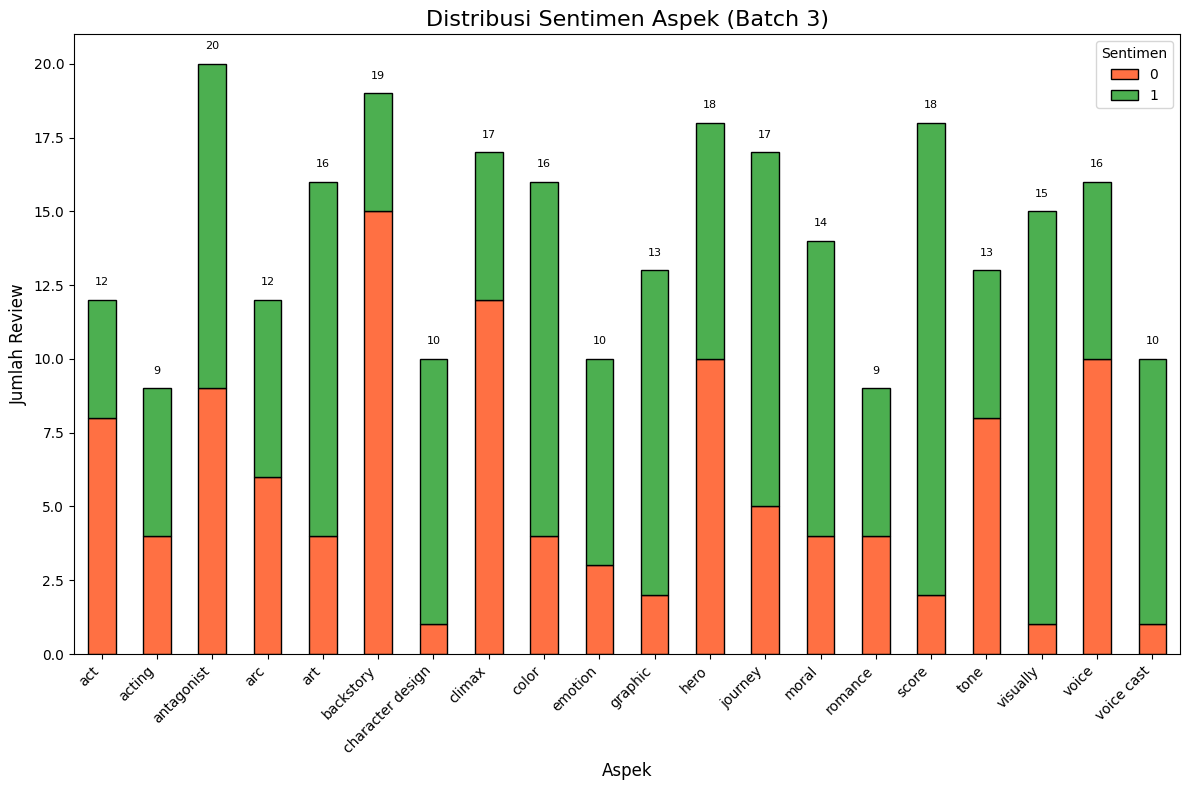

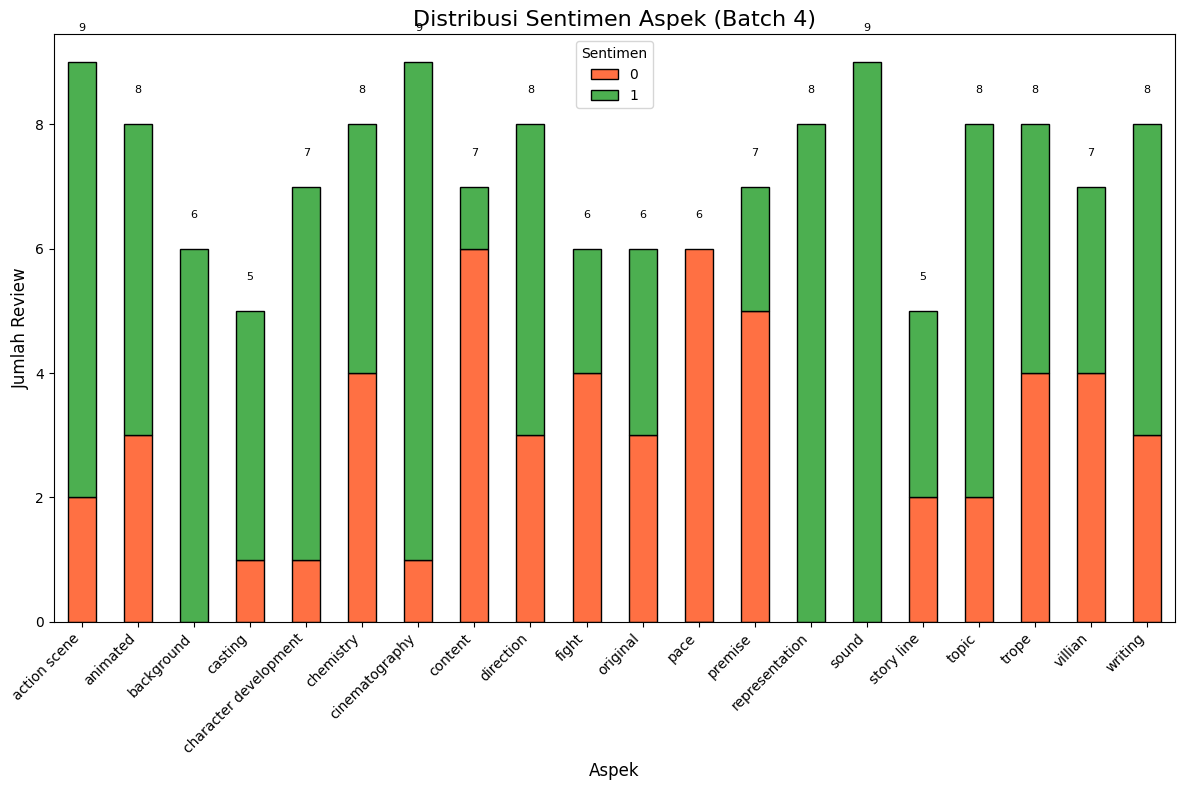

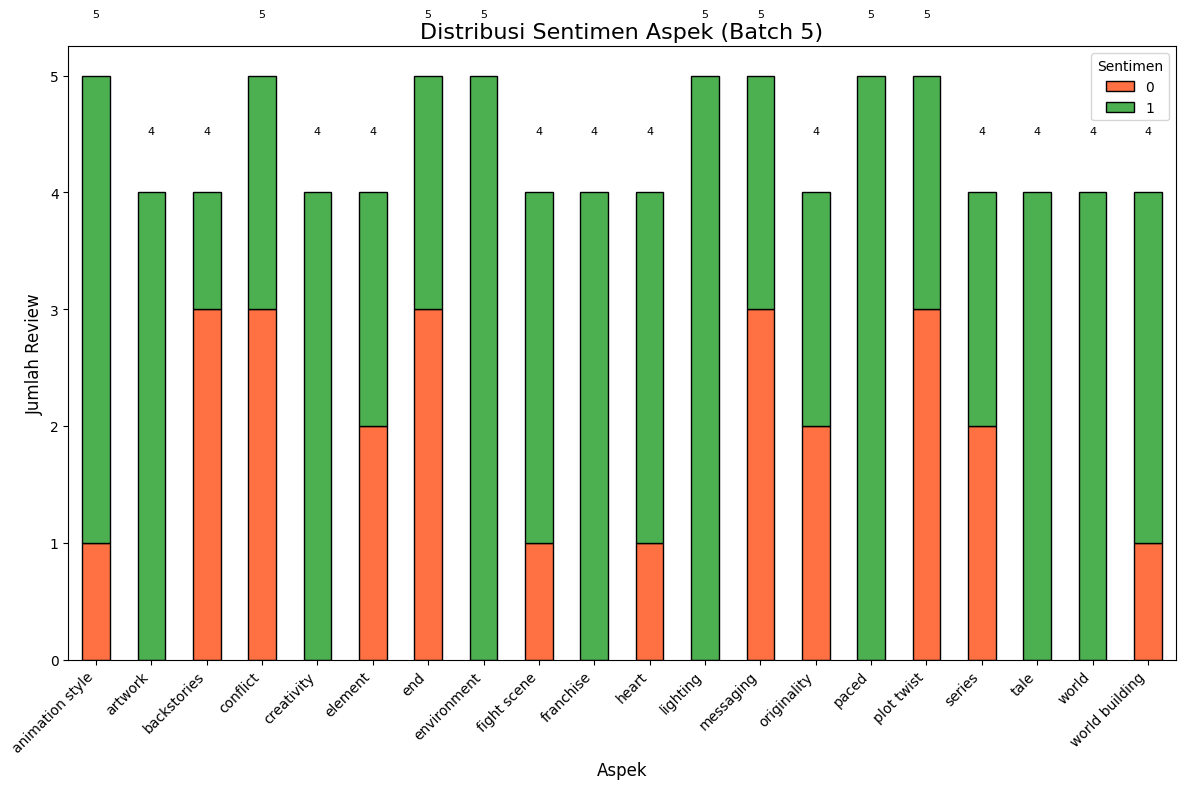

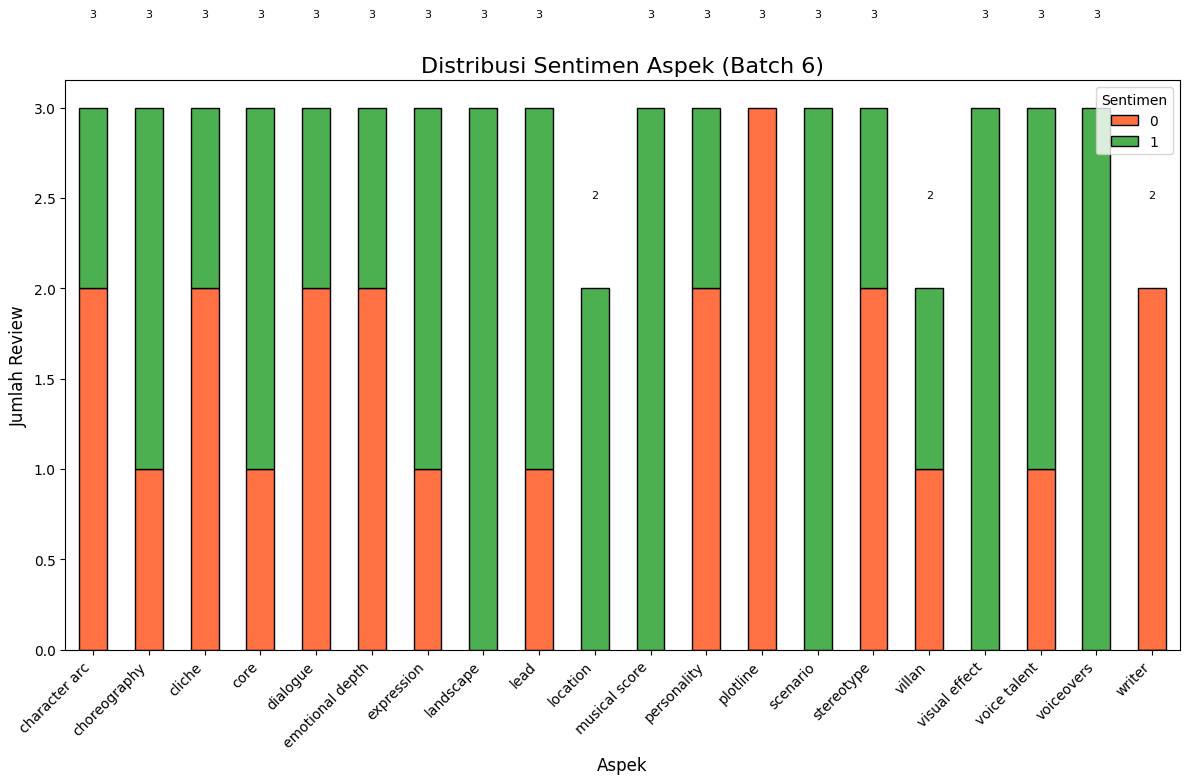

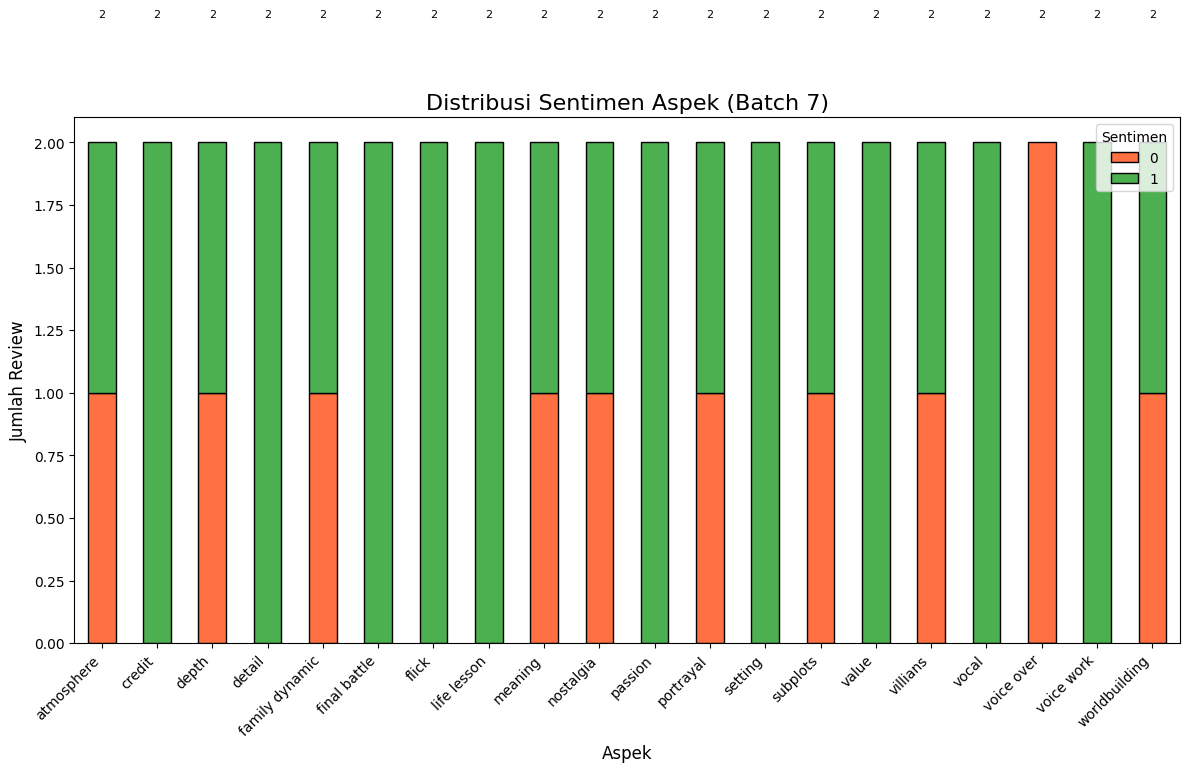

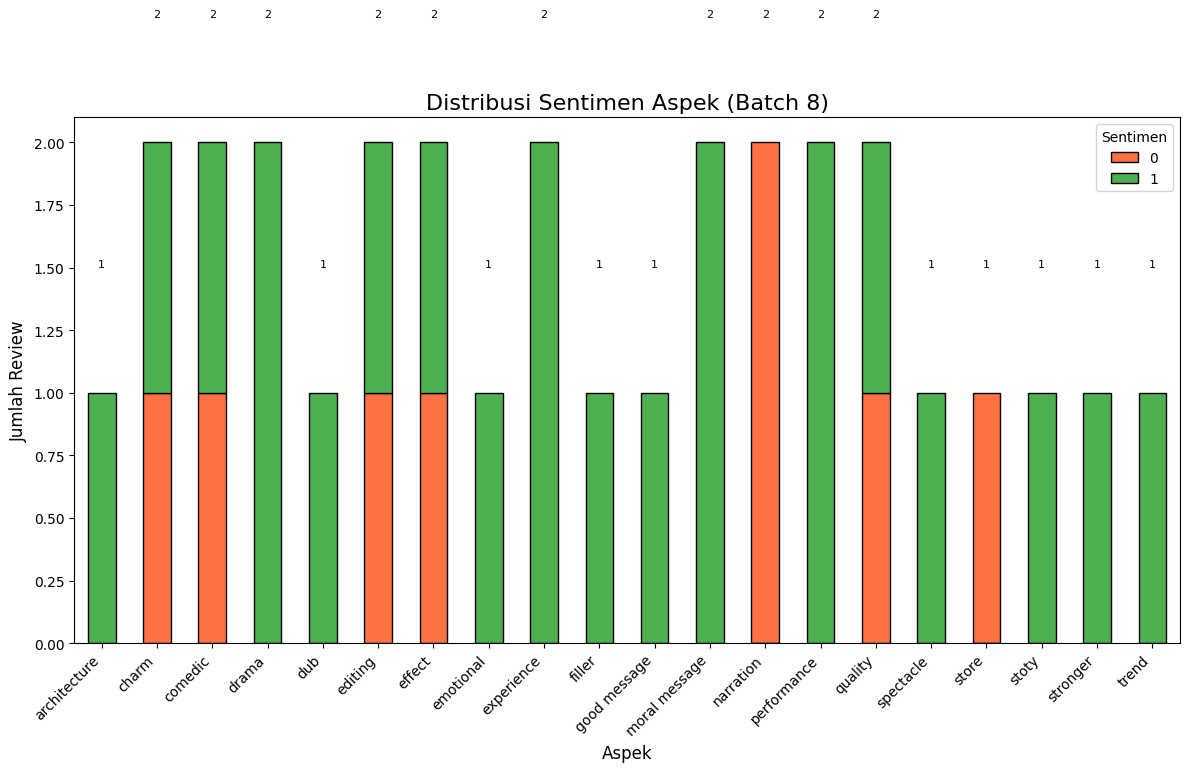

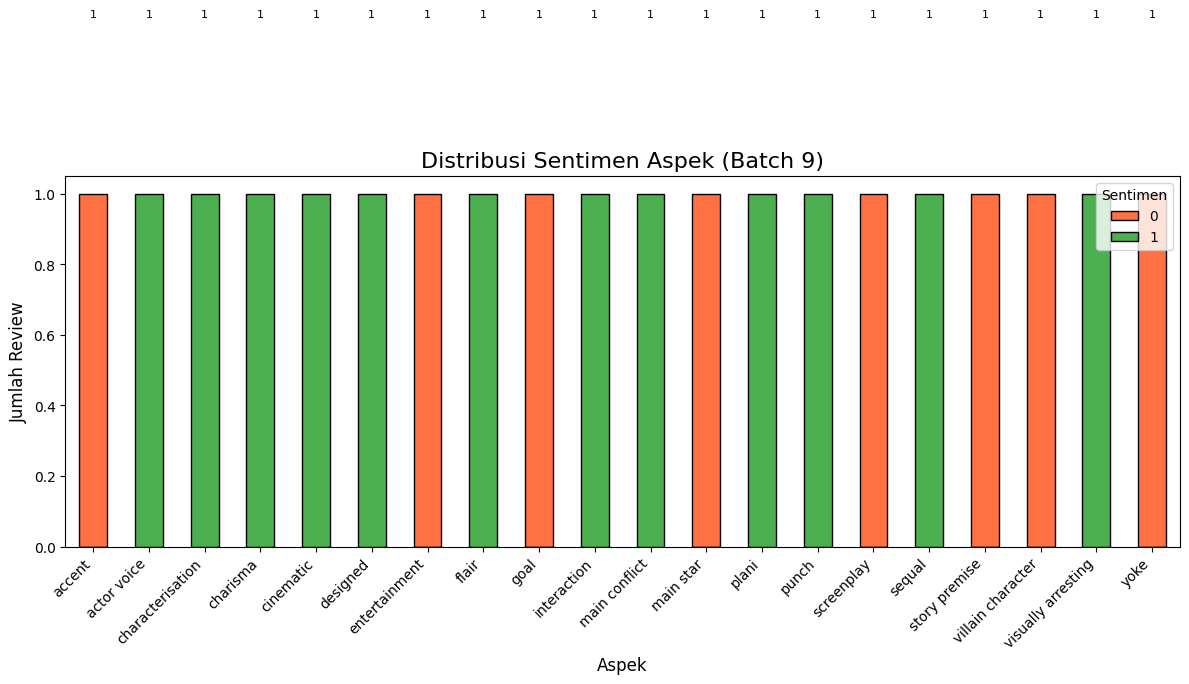

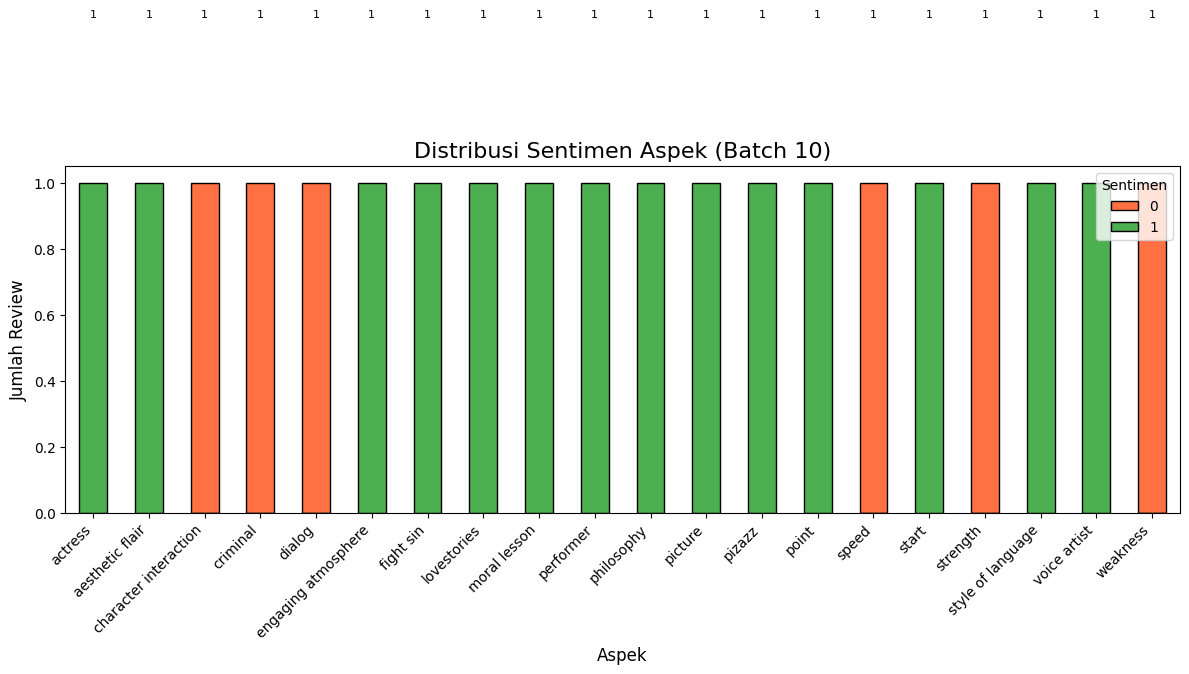

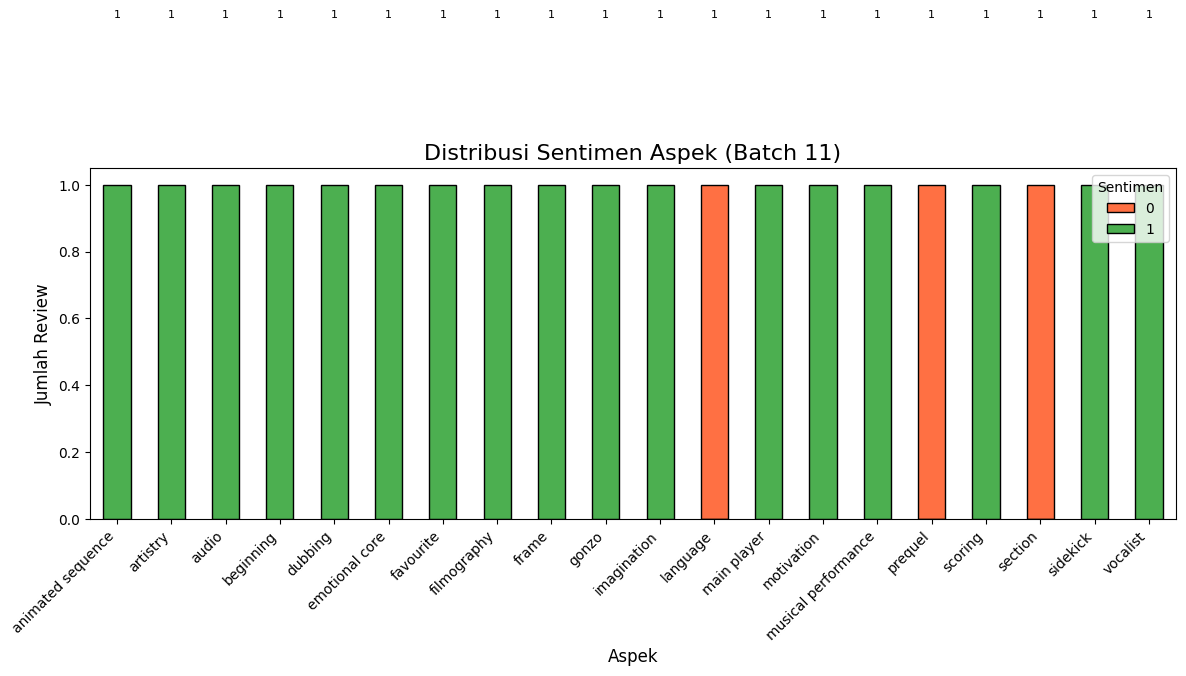

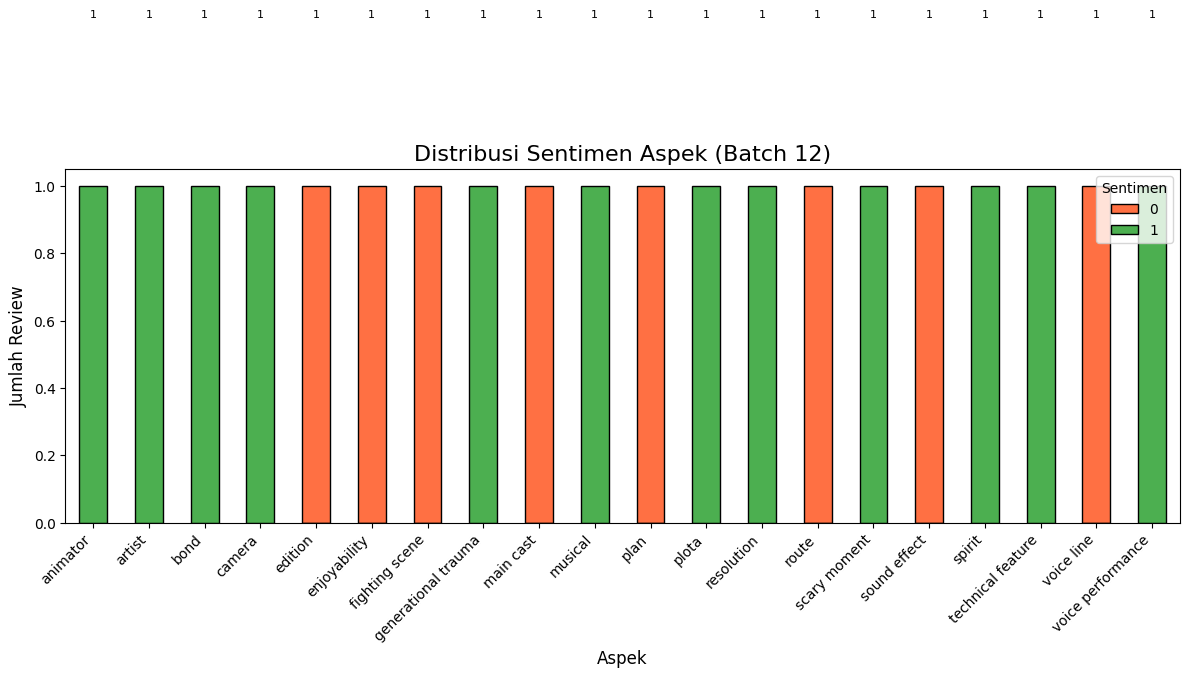

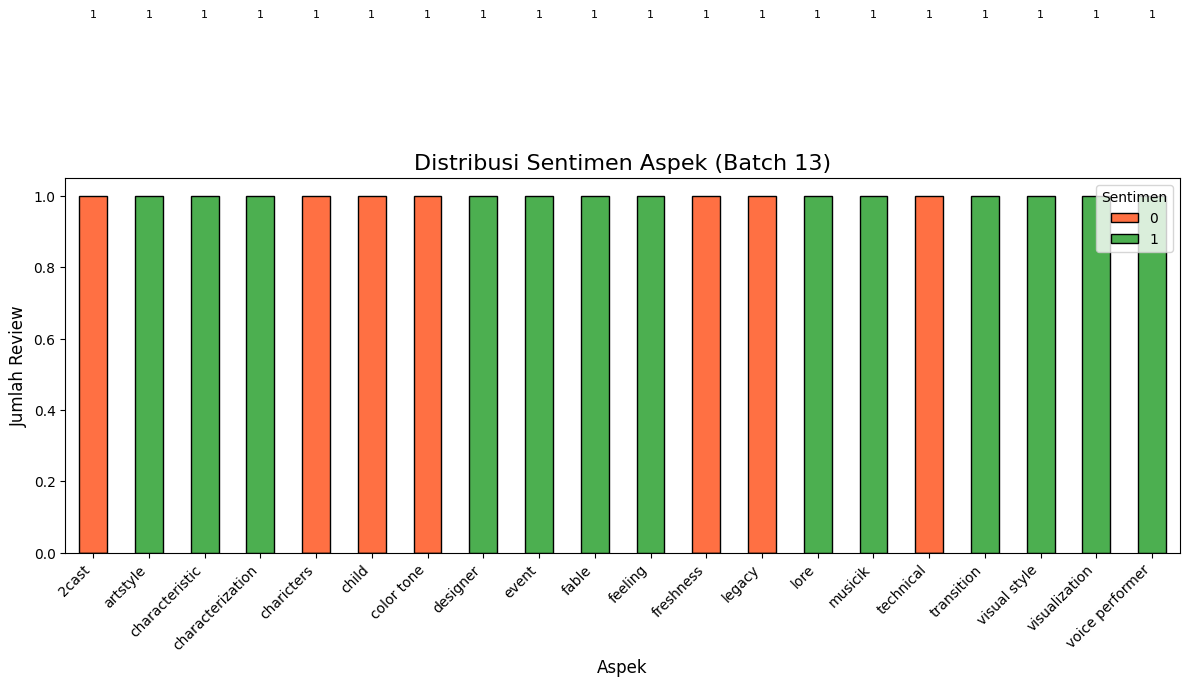

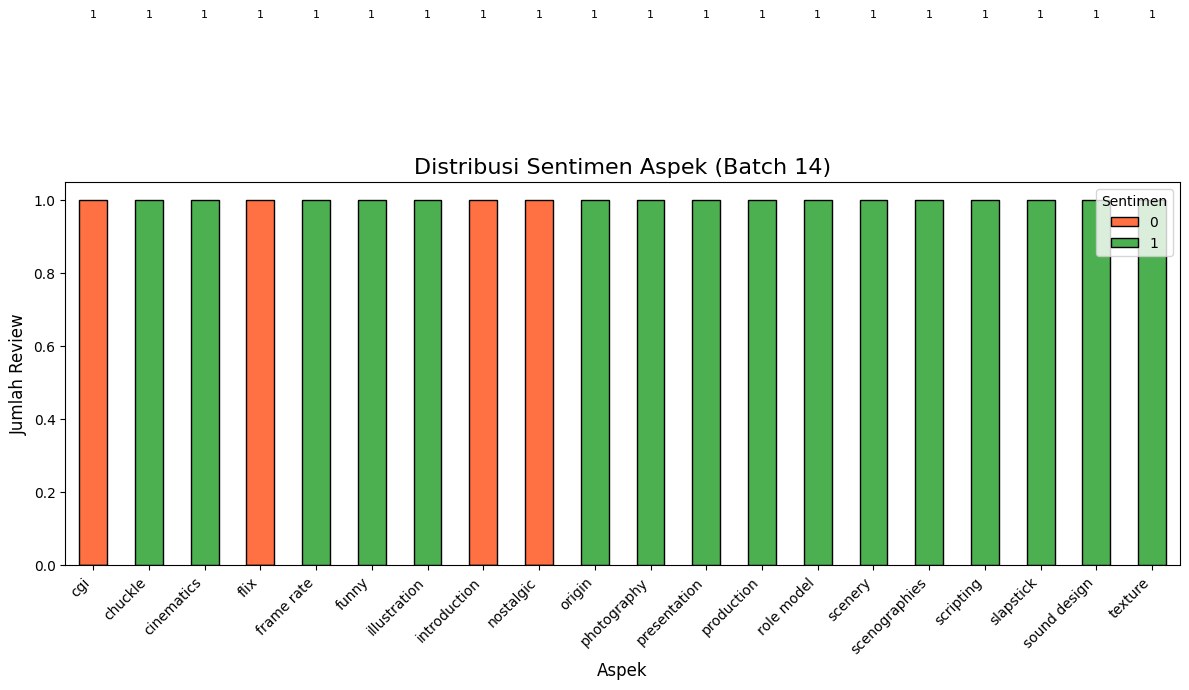

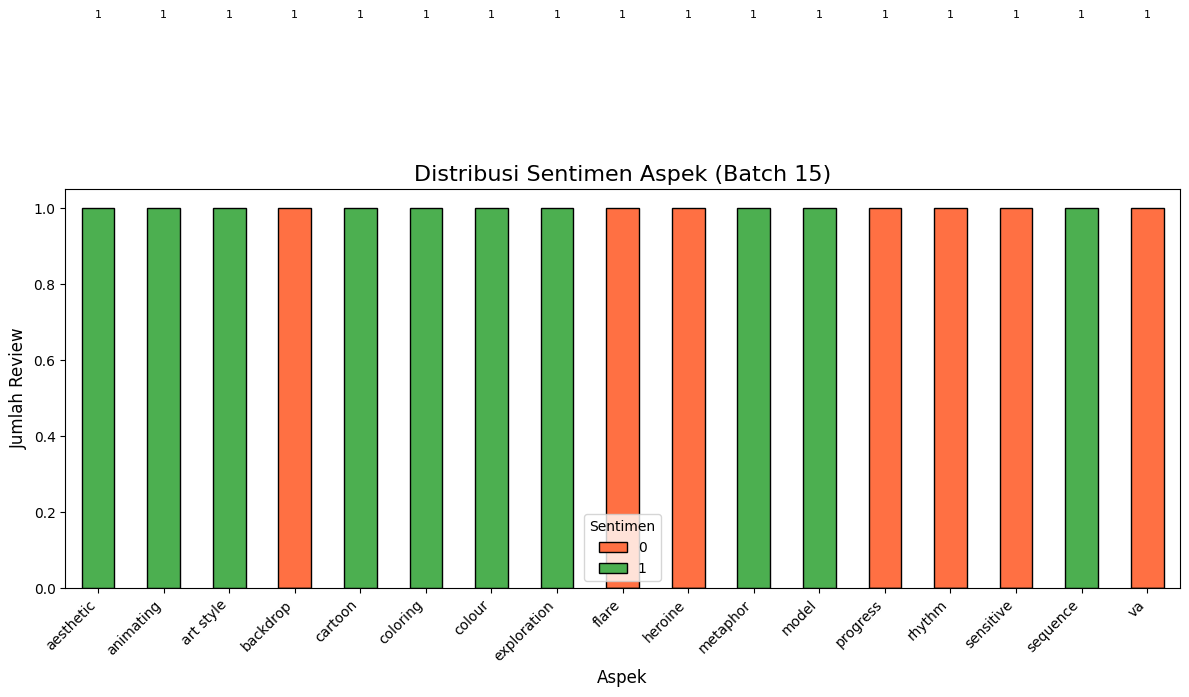

In [ ]:
# --- 5. Loop per batch untuk membuat stacked bar ---
for batch in range(num_batches):
    start_idx = batch * batch_size
    end_idx = start_idx + batch_size
    aspects_batch = all_aspects[start_idx:end_idx]

    df_batch = df[df['aspect'].isin(aspects_batch)]

    # Pivot table untuk stacked bar
    pivot_df = df_batch.groupby(['aspect', 'sentiment']).size().unstack(fill_value=0)

    # Plot stacked bar
    ax = pivot_df.plot(kind='bar', stacked=True, figsize=(12, 8),
                       color=['#FF7043', '#4CAF50'], edgecolor='black')

    plt.title(f'Distribusi Sentimen Aspek (Batch {batch+1})', fontsize=16)
    plt.xlabel('Aspek', fontsize=12)
    plt.ylabel('Jumlah Review', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Sentimen')

    # Tambahkan label total di atas bar
    for idx, aspect in enumerate(pivot_df.index):
        total = pivot_df.loc[aspect].sum()
        plt.text(idx, total + 0.5, str(total), ha='center', fontsize=8)

    plt.tight_layout()
    plt.show()